# Cifar10 Separation

The task consists in taking in input an image obtained as a mean of two Cifar10 samples, predicting the correct label for each component. The first image is taken from the first 5 categories (airplane, automobile, bird, cat, deer), while the second one is taken from the remaining ones (dog, frog, horse, ship, truck). The network is supposed to return two labels, each one in a range of 5 categories.

The metrics used to evaluate the model is the mean accurary of the preditions relative to the first and second image: that is, measure the classification accuracy for the first image, then for the second, and take the mean.

The metric should be evaluated over 10000 test images randomly generated.
Repeat the computation ten times and provide the standard deviation.

Below we provide a generator and some examples.

#Data Preparation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
(cifar10_x_train, cifar10_y_train), (cifar10_x_test, cifar10_y_test) = cifar10.load_data()
assert cifar10_x_train.shape == (50000, 32, 32, 3)
assert cifar10_x_test.shape == (10000, 32, 32, 3)
assert cifar10_y_train.shape == (50000, 1)
assert cifar10_y_test.shape == (10000, 1)

classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

cifar10_x_train = (cifar10_x_train/255.).astype(np.float32)
cifar10_x_test = (cifar10_x_test/255.).astype(np.float32)

We separate images in two sets, according to their label.

In [ ]:
cond_1 = cifar10_y_train[:,0] < 5
cifar10_x_train_1 = cifar10_x_train[cond_1]
cifar10_y_train_1 = cifar10_y_train[cond_1]

cond_2 = cifar10_y_train[:,0] >= 5
cifar10_x_train_2 = cifar10_x_train[cond_2]
cifar10_y_train_2 = cifar10_y_train[cond_2]

cond_1_test = cifar10_y_test[:,0] < 5
cifar10_x_test_1 = cifar10_x_test[cond_1_test]
cifar10_y_test_1 = cifar10_y_test[cond_1_test]

cond_2_test = cifar10_y_test[:,0] >= 5
cifar10_x_test_2 = cifar10_x_test[cond_2_test]
cifar10_y_test_2 = cifar10_y_test[cond_2_test]

Here is the data generator. it takes in input two datasets (X1,X2), the corresponding labels (Y1,Y2) and a batchsize.

It returns x_data, y_data, where

*   x_data is a batch of images obtained as a mean of random samples in X1 and X2
*   y_data is a pair of batches of labels relative to the components, already expressed in categorical format



In [ ]:
def datagenerator(X1, X2, Y1, Y2, batchsize):

  size1 = X1.shape[0]
  size2 = X2.shape[0]
  Y1_cat = tf.keras.utils.to_categorical(Y1, num_classes=5)
  Y2_cat = tf.keras.utils.to_categorical(Y2-5, num_classes=5)

  while True:

    num1 = np.random.randint(0, size1, batchsize)
    num2 = np.random.randint(0, size2, batchsize)

    x_data = (X1[num1] + X2[num2]) / 2.0
    y_data = [Y1_cat[num1], Y2_cat[num2]]

    yield x_data, y_data
    #yield x_data, y_data, int(num1), int(num2)     # Per visualizzare le immagini di partenza (possibile con batchsize=1)

# Esempio

Let instantiate a generator with batchsize=1, to test its behaviour.

In [ ]:
datagen = datagenerator(cifar10_x_train_1, cifar10_x_train_2, cifar10_y_train_1, cifar10_y_train_2, 1)

Let's generate an example, show the input image and print the category of the original images.

You can repeat the execution of the cell to see more examples.

shape:
	x: (1, 32, 32, 3)
	y: (2, 1, 5) 


#####


first: cat, second: frog

pixel range is [0.04313725605607033,0.7803921699523926]


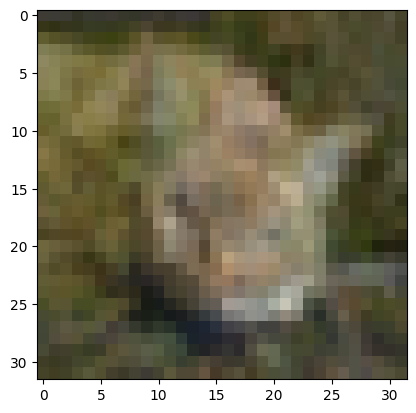

In [ ]:
x, y = next(datagen)
print("shape:\n\tx: {}\n\ty: {}".format(np.asarray(x).shape, np.asarray(y).shape), "\n\n\n#####\n\n")

# Per visualizzare le immagini di partenza (possibile con batchsize=1)
#x, y, num_X1, num_X2 = next(datagen)
#print("shape:\n\tx: {}\n\ty: {}\n\tnum1: {}\n\tnum2: {}".format(np.asarray(x).shape, np.asarray(y).shape, np.asarray(num_X1).shape, np.asarray(num_X2).shape), "\n\n\n#####\n\n")


print("first: {}, second: {}".format(classes[np.argmax(y[0][0])], classes[np.argmax(y[1][0])+5]))

print("\npixel range is [{},{}]".format(np.min(x[0]), np.max(x[0])))

plt.imshow(x[0])

In [ ]:
# Per visualizzare le immagini di partenza (possibile con batchsize=1)
#fig, ax = plt.subplots(1,2)
#ax[0].imshow(cifar10_x_train_1[num_X1]);
#ax[1].imshow(cifar10_x_train_2[num_X2]);

# Modello

Create the model

In [ ]:
input_layer = layers.Input(shape=(32,32,3))

x = layers.Conv2D(filters=4, kernel_size=(3,3), strides=(2,2), padding='valid')(input_layer)

x = layers.Flatten()(x)

output_activation_fn = 'softmax'
output_layer_1 = layers.Dense(5, activation=output_activation_fn)(x)      # 5 = numero di categorie possibili per ogni output
output_layer_2 = layers.Dense(5, activation=output_activation_fn)(x)


rete = Model(inputs=input_layer, outputs=[output_layer_1, output_layer_2])      # Ho 2 output, per ritornare le 2 etichette (in formato categorico)
rete.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 15, 15, 4)    112         ['input_1[0][0]']                
                                                                                                  
 flatten (Flatten)              (None, 900)          0           ['conv2d[0][0]']                 
                                                                                                  
 dense (Dense)                  (None, 5)            4505        ['flatten[0][0]']                
                                                                                              

Compile the model

In [ ]:
rete.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])       # categorical_accuracy: calculates how often predictions match one-hot labels

Fit the model

In [ ]:
# Callback per misurare la mean accuracy dell'accuracy dei due output
class MeanAccuracyMetrics(tf.keras.callbacks.Callback):         # Callbacks: utilities called at certain points during model training.

    def __init__(self, **kargs):
        super(MeanAccuracyMetrics, self).__init__(**kargs)

    def on_epoch_begin(self, epoch, logs={}):
        return

    # Alla fine di ogni epoch del fit
    def on_epoch_end(self, epoch, logs={}):
        logs['mean_accuracy'] = (logs[rete.metrics_names[3]] + logs[rete.metrics_names[4]]) / 2       # (dense_categorical_accuracy + dense_1_categorical_accuracy) / 2

In [ ]:
compute_mean_accuracy = MeanAccuracyMetrics()     # Callback

rete.fit(x = datagenerator(cifar10_x_train_1, cifar10_x_train_2, cifar10_y_train_1, cifar10_y_train_2, 1),      # Con batchsize=1 prende in input 1 immagine (come media di 2 immagini) e ritorna 2 label
         steps_per_epoch = 50000,
         epochs = 10,
         callbacks = [compute_mean_accuracy])    # Per calcolare la mean accuracy

Epoch 1/10
50000/50000 [==============================] - 234s 5ms/step - loss: 2.7930 - dense_loss: 1.4363 - dense_1_loss: 1.3567 - dense_categorical_accuracy: 0.3973 - dense_1_categorical_accuracy: 0.4420 - mean_accuracy: 0.4196
Epoch 2/10
50000/50000 [==============================] - 224s 4ms/step - loss: 2.7349 - dense_loss: 1.4124 - dense_1_loss: 1.3225 - dense_categorical_accuracy: 0.4085 - dense_1_categorical_accuracy: 0.4642 - mean_accuracy: 0.4363
Epoch 3/10
50000/50000 [==============================] - 224s 4ms/step - loss: 2.7183 - dense_loss: 1.4037 - dense_1_loss: 1.3145 - dense_categorical_accuracy: 0.4153 - dense_1_categorical_accuracy: 0.4672 - mean_accuracy: 0.4412
Epoch 4/10
50000/50000 [==============================] - 223s 4ms/step - loss: 2.7151 - dense_loss: 1.4041 - dense_1_loss: 1.3110 - dense_categorical_accuracy: 0.4155 - dense_1_categorical_accuracy: 0.4678 - mean_accuracy: 0.4417
Epoch 5/10
50000/50000 [==============================] - 222s 4ms/step - lo

Evaluate the model

In [ ]:
cvscores = []

for i in range(0, 10):      # Ripeti 10 volte

    # evaluate: Returns the loss value & metrics values for the model in test mode.
    scores = rete.evaluate(x = datagenerator(cifar10_x_test_1, cifar10_x_test_2, cifar10_y_test_1, cifar10_y_test_2, 1),      # Con batchsize=1 prende in input 1 immagine (come media di 2 immagini) e ritorna 2 label
                          steps = 10000,     # Total number of steps (batches of samples) before declaring the evaluation round finished
                          verbose = 0)

    mean_accuracy = (scores[3] + scores[4]) / 2             # (dense_categorical_accuracy + dense_1_categorical_accuracy) / 2
    print("%i) %s: %.2f%%" % (i+1, "Mean accuracy", mean_accuracy * 100))
    cvscores.append(mean_accuracy * 100)

print("------------------------------")
# Media e deviazione standard delle 10 accuratezze
print("Total mean accuracy: %.2f%% (+/- %.2f%% standard deviation)" % (np.mean(cvscores), np.std(cvscores)))

1) Mean accuracy: 41.79%
2) Mean accuracy: 42.26%
3) Mean accuracy: 41.85%
4) Mean accuracy: 41.94%
5) Mean accuracy: 42.77%
6) Mean accuracy: 42.58%
7) Mean accuracy: 41.98%
8) Mean accuracy: 42.62%
9) Mean accuracy: 43.13%


KeyboardInterrupt: ignored